# TASKS

AUC Score = 0.9977071732721913


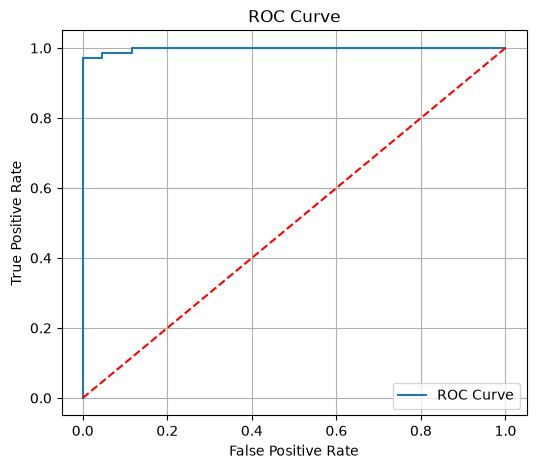

In [2]:
#Plot ROC Curve and Calculate AUC for Logistic Regression
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, threshold = roc_curve(y_test, y_prob)

# AUC Score
auc = roc_auc_score(y_test, y_prob)
print("AUC Score =", auc)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [4]:
#Use GridSearchCV to Tune Random Forest Hyperparameters
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
rf = RandomForestClassifier(random_state=42)

# Hyperparameters
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

# Grid Search
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Accuracy:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}

Best Accuracy:
0.9626373626373625


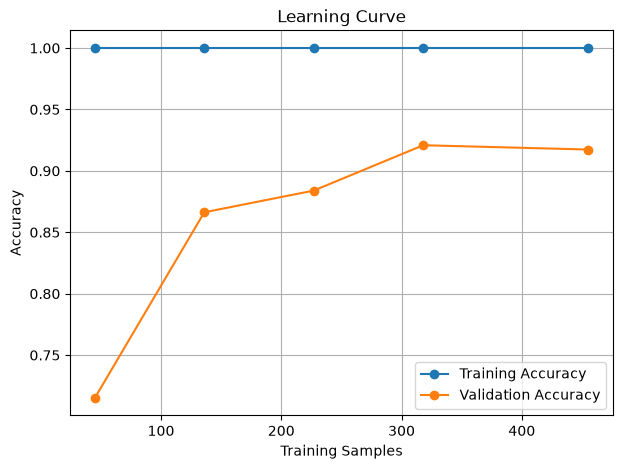

In [6]:
#Plot Learning Curves to Diagnose Bias/Variance
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import learning_curve

# Load data
data = load_breast_cancer()
X = data.data
y = data.target

# Model
model = DecisionTreeClassifier(random_state=42)

# Learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=[0.1,0.3,0.5,0.7,1.0]
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Plot
plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker="o", label="Training Accuracy")
plt.plot(train_sizes, test_mean, marker="o", label="Validation Accuracy")

plt.title("Learning Curve")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

In [8]:
#Build a Metrics Comparison Table for Three Models
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

# Create DataFrame
df = pd.DataFrame(results,
                  columns=[
                      "Model",
                      "Accuracy",
                      "Precision",
                      "Recall",
                      "F1-Score"
                  ])

print(df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.956140   0.945946  0.985915  0.965517
1        Decision Tree  0.947368   0.957746  0.957746  0.957746
2        Random Forest  0.964912   0.958904  0.985915  0.972222


# PRATICE

In [10]:
#Full Model Comparison Pipeline (Train 5 Models and Rank by F1-Score)
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Load Dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

results = []

# Train and Evaluate
for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

# Create DataFrame
df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

# Rank by F1 Score
df = df.sort_values(
    by="F1-Score",
    ascending=False
)

print("\n===== Model Ranking =====")
print(df)


===== Model Ranking =====
                 Model  Accuracy  Precision    Recall  F1-Score
2        Random Forest  0.964912   0.958904  0.985915  0.972222
4                  KNN  0.956140   0.934211  1.000000  0.965986
0  Logistic Regression  0.956140   0.945946  0.985915  0.965517
3                  SVM  0.947368   0.922078  1.000000  0.959459
1        Decision Tree  0.947368   0.957746  0.957746  0.957746


In [12]:
#Tune SVM Using GridSearchCV and Report Best Parameters
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC

# Load Dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Model
svm = SVC()

# Hyperparameter Grid
parameters = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

# Grid Search
grid = GridSearchCV(
    estimator=svm,
    param_grid=parameters,
    cv=5,
    scoring="accuracy"
)

# Train
grid.fit(X_train, y_train)

# Best Results
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

# Best Model
best_model = grid.best_estimator_

# Test Accuracy
accuracy = best_model.score(X_test, y_test)

print("\nTest Accuracy:")
print(accuracy)

Best Parameters:
{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}

Best Cross Validation Accuracy:
0.9714285714285715

Test Accuracy:
0.956140350877193
